## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Chargement des données

In [2]:
df=pd.read_csv('social_media_vs_productivity.csv')
df.head(10)

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
5,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
6,56,Female,Unemployed,4.381070,TikTok,60,3.902309,6.420989,5.976408,7.0,7.549849,2.252624,4,False,False,4,20,24.084905,5.501373
7,36,Female,Education,4.089168,Twitter,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,False,False,4,29,8.419648,3.444376
8,40,Female,Education,4.097401,Instagram,57,5.839590,3.219022,3.004240,4.0,NaN,0.000000,10,False,True,2,10,0.000000,1.960131
9,28,Other,IT,7.595577,Twitter,64,5.888936,NaN,NaN,3.0,6.761952,1.449841,10,False,False,1,18,6.959377,6.808102


## Comprendre la structure des données

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  str    
 2   job_type                        30000 non-null  str    
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  str    
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              30000 non-n

In [4]:
df.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,27235.000000,30000.000000,30000.000000,28386.000000,27635.000000,28096.000000,27402.000000,27789.000000,30000.000000,30000.000000,30000.000000,30000.000000,27270.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,2.074813,7.723772,1.997736,2.023470,1.883378,2.866344,1.464004,0.653355,3.173737,1.410047,9.252956,7.280415,2.121194
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.639566,55.000000,5.643771,3.757861,3.373284,3.000000,5.493536,0.528490,2.000000,1.000000,8.000000,4.541872,3.363580
50%,41.000000,3.025913,60.000000,6.990641,5.525005,4.951742,6.000000,6.498340,1.006159,5.000000,2.000000,16.000000,10.013677,4.951049
75%,53.000000,4.368917,65.000000,8.354725,7.265776,6.526342,8.000000,7.504143,1.477221,8.000000,3.000000,24.000000,15.300809,6.581323
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


## Approches statistiques: 
Pour les valeurs catégorielles, nous allons utiliser des graphiques à barres pour visualiser la distribution des différentes catégories. Pour les valeurs numériques, nous allons utiliser des histogrammes pour visualiser la distribution des données.

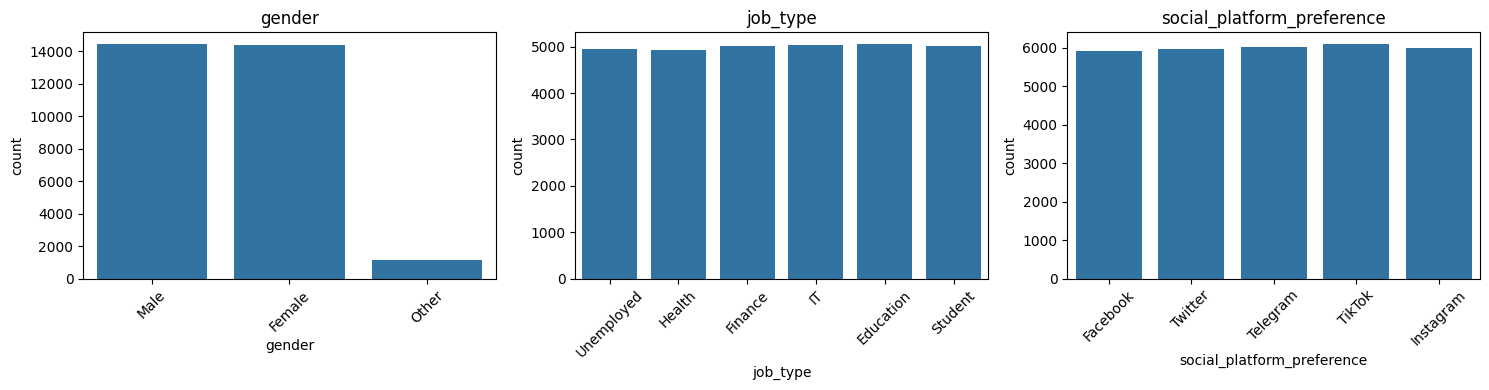

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ['gender', 'job_type', 'social_platform_preference']
for ax, col in zip(axes, cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

On peut remarquer que le dataset est assez équilibré sur la parité, le type de travail et le type de réseaux sociaux de référence des utilisateurs.

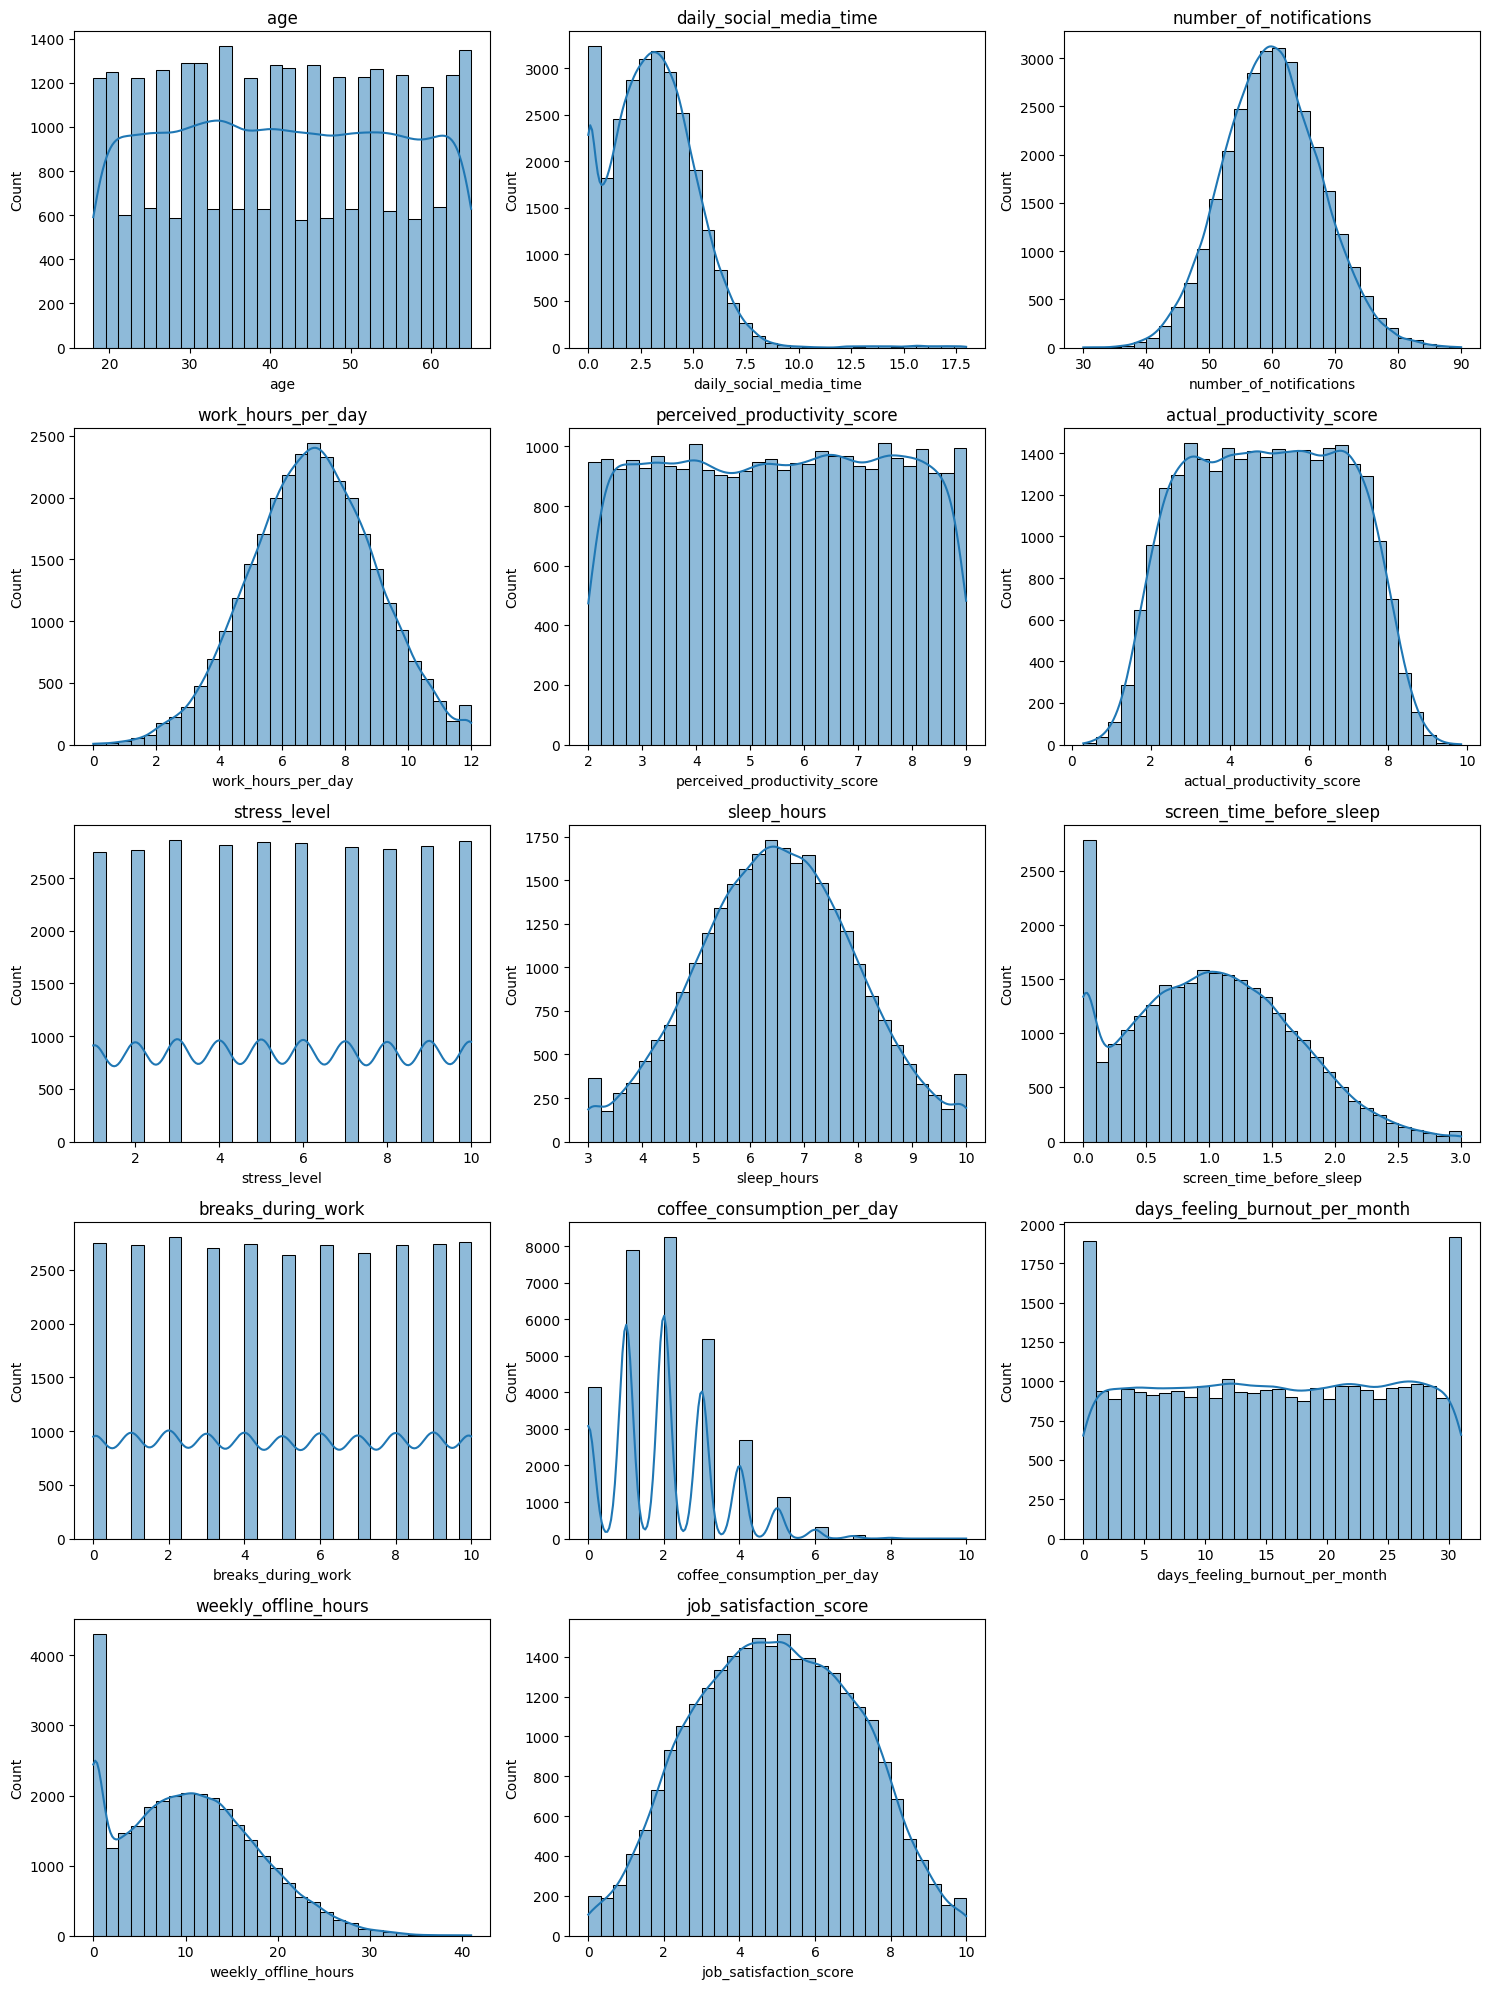

In [6]:
cols = ['age','daily_social_media_time','number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']
available = [c for c in cols if c in df.columns]
num_cols = df[available].select_dtypes(include=[np.number]).columns.tolist()

n = len(num_cols)
cols_per_row = 3
nrows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(nrows, cols_per_row, figsize=(cols_per_row*5, nrows*4))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax, col in zip(axes, num_cols):
        sns.histplot(data=df, x=col, kde=True, bins=30, ax=ax, color='C0')
        ax.set_title(col)
for ax in axes[len(num_cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

## Détecter les doublons 

In [ ]:
df.duplicated().sum()

np.int64(0)

Aucun doublon détécté.

## Détecter les valeurs manquantes

In [7]:
df.isnull().sum()

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

## Détecter les valeurs aberrantes 

<Axes: xlabel='age'>

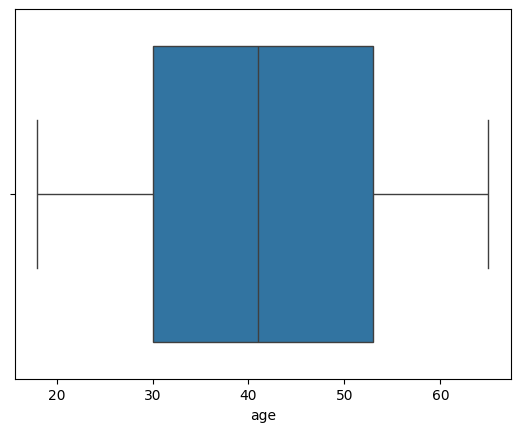

In [7]:
sns.boxplot(x="age", data=df)

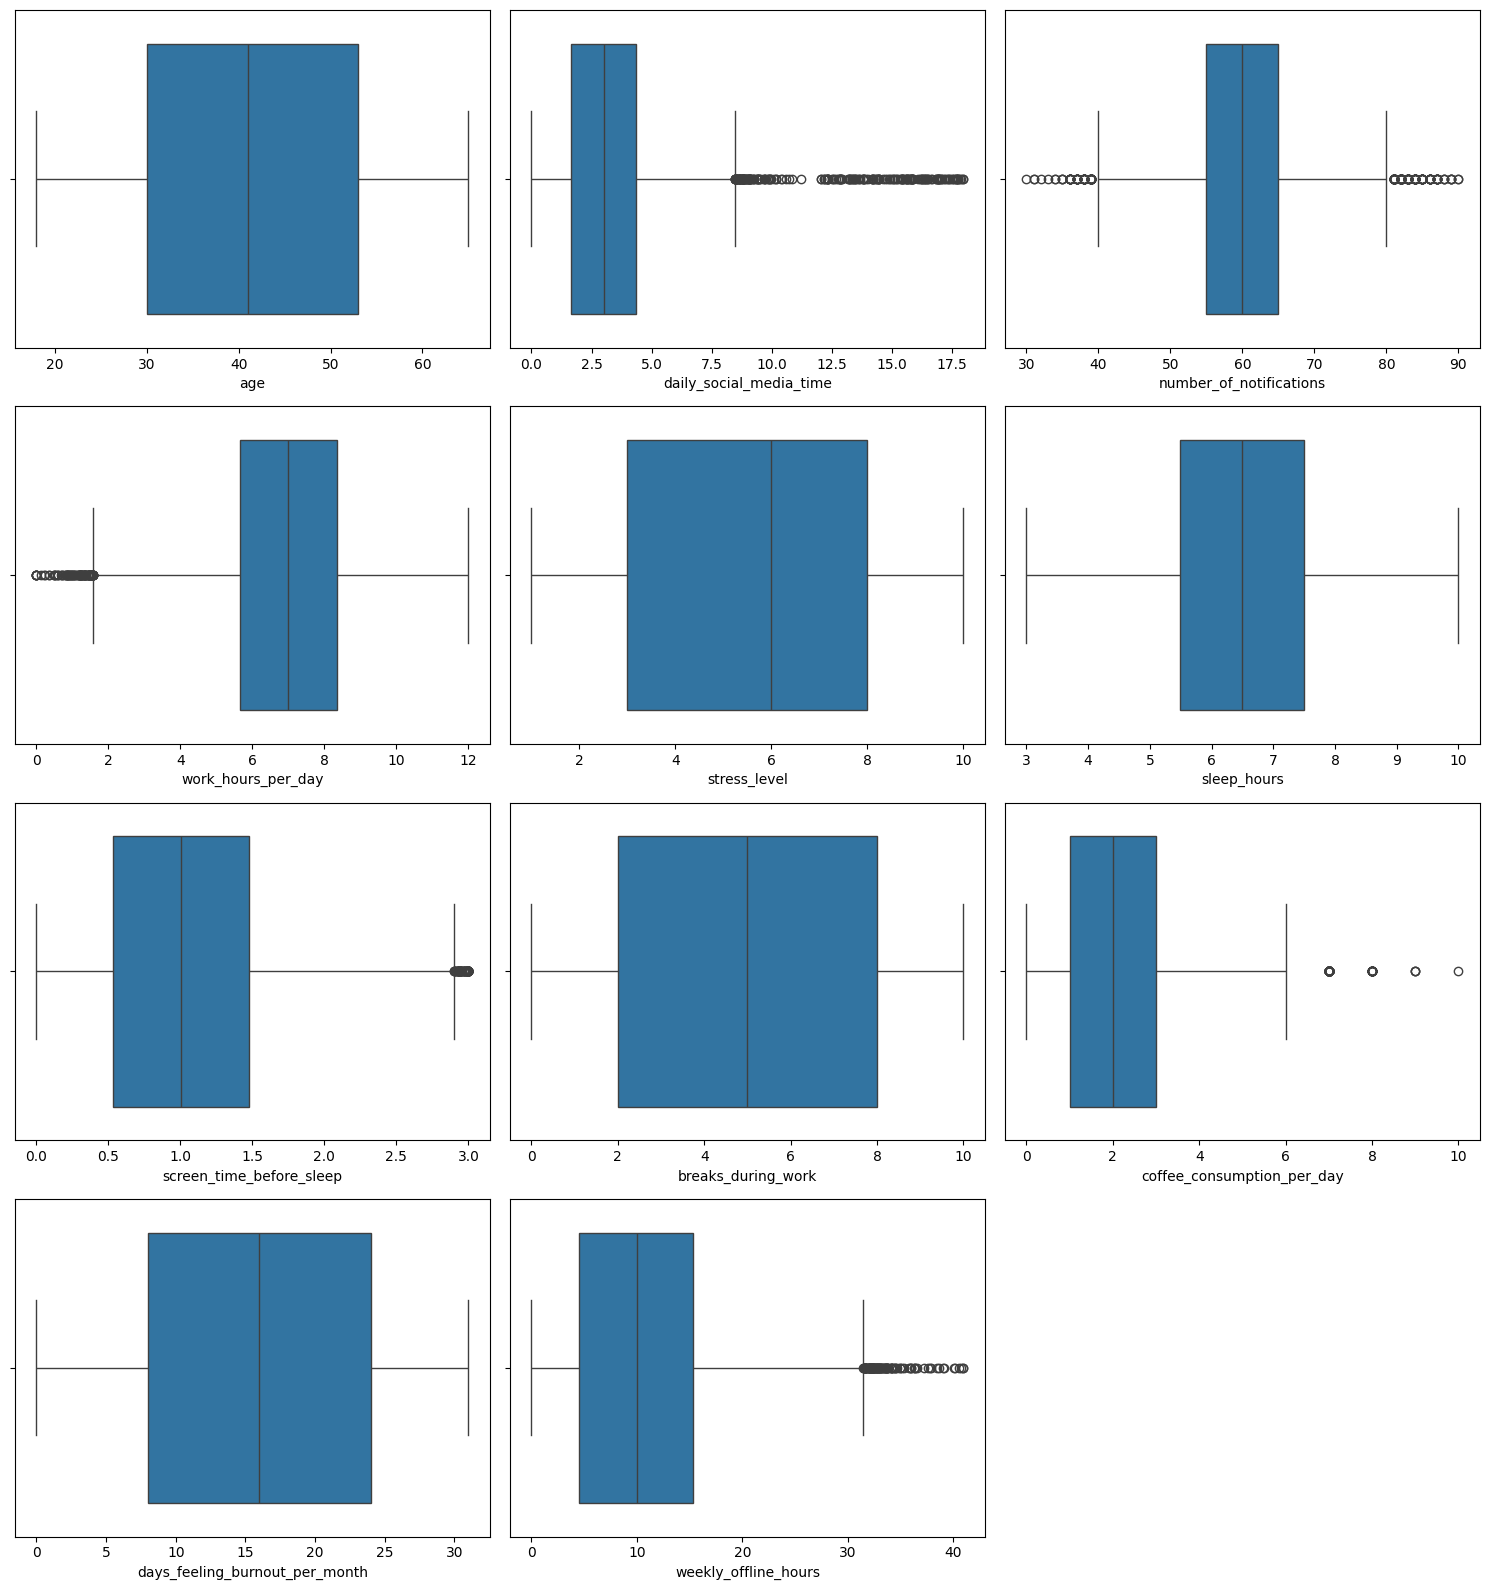

In [8]:
cols = ['age','daily_social_media_time','number_of_notifications', 'work_hours_per_day', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours']
available = [c for c in cols if c in df.columns]
num_cols = df[available].select_dtypes(include=[np.number]).columns.tolist()

n = len(num_cols)
cols_per_row = 3
nrows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(nrows, cols_per_row, figsize=(cols_per_row*5, max(1, nrows)*4))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax, col in zip(axes, num_cols):
        sns.boxplot(x=df[col], ax=ax)
for ax in axes[len(num_cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

Données aberrantes: Un temps passé sur les réseaux sociaux supérieur à 15 heures. 
Outliers: moins de 2 heures de travail par jour, plus de 30 heures par jour déconnecté des réseaux sociaux en excluant le temps de sommeil. 
Ces données ne seront pas prises en compte pour notre étude car elles peuvent etre associées à un type de profil qui n'utilise pas les réseaux sociaux ou qui est au chomage.

## Vérifier le typage

In [9]:
df.dtypes

age                                 int64
gender                                str
job_type                              str
daily_social_media_time           float64
social_platform_preference            str
number_of_notifications             int64
work_hours_per_day                float64
perceived_productivity_score      float64
actual_productivity_score         float64
stress_level                      float64
sleep_hours                       float64
screen_time_before_sleep          float64
breaks_during_work                  int64
uses_focus_apps                      bool
has_digital_wellbeing_enabled        bool
coffee_consumption_per_day          int64
days_feeling_burnout_per_month      int64
weekly_offline_hours              float64
job_satisfaction_score            float64
dtype: object

## Gestion des valeurs aberrantes et des outliers

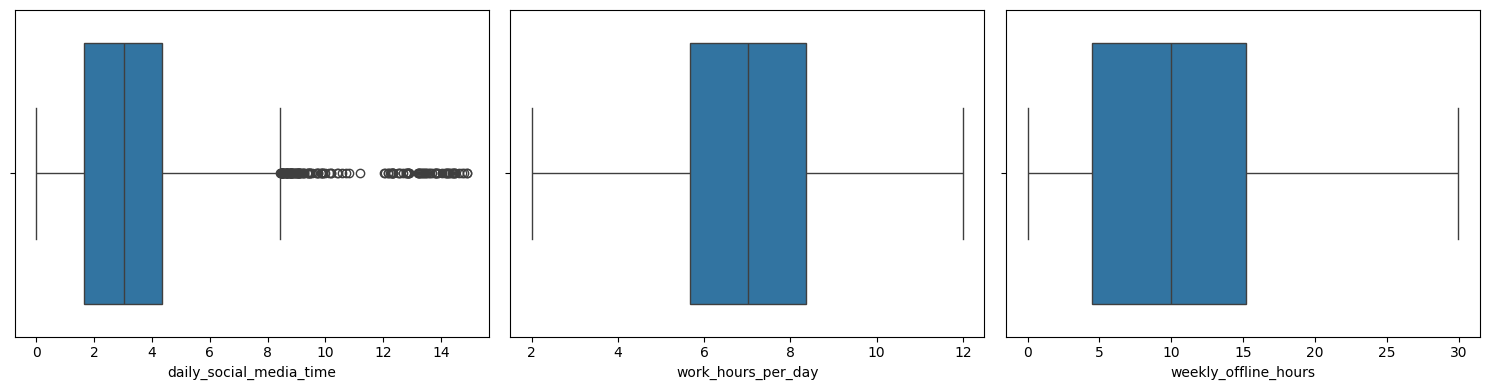

In [10]:
df = df.drop(df[df['daily_social_media_time']>15].index)
df=df.drop(df[df['work_hours_per_day']<2].index)
df=df.drop(df[df['weekly_offline_hours']>30].index)
cols = ['daily_social_media_time','work_hours_per_day','weekly_offline_hours']
available = [c for c in cols if c in df.columns]
num_cols = df[available].select_dtypes(include=[np.number]).columns.tolist()

n = len(num_cols)
cols_per_row = 3
nrows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(nrows, cols_per_row, figsize=(cols_per_row*5, max(1, nrows)*4))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax, col in zip(axes, num_cols):
        sns.boxplot(x=df[col], ax=ax)
for ax in axes[len(num_cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

## Cas des valeurs manquantes

In [11]:
df['actual_productivity_score'].fillna(df['actual_productivity_score'].median(), inplace=True)
df['perceived_productivity_score'].fillna(df['perceived_productivity_score'].median(), inplace=True)
df['job_satisfaction_score'].fillna(df['job_satisfaction_score'].median(), inplace=True)
df['daily_social_media_time'].fillna(df['daily_social_media_time'].median(), inplace=True)
df['actual_productivity_score'].fillna(df['actual_productivity_score'].median(), inplace=True)
df['stress_level'].fillna(df['stress_level'].median(), inplace=True)
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)
df['screen_time_before_sleep'].fillna(df['screen_time_before_sleep'].median(), inplace=True)

C:\Users\mrand\AppData\Local\Temp\ipykernel_20524\179227076.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['actual_productivity_score'].fillna(df['actual_productivity_score'].median(), inplace=True)
C:\Users\mrand\AppData\Local\Temp\ipykernel_20524\179227076.py:2: ChainedAssignmentError: A value is being set on a copy of a Da

0        0.419102
1        0.671519
2        0.624378
3        1.204540
4        1.876254
           ...   
29994    1.447903
29995    1.412655
29996    0.148936
29998    0.234483
29999    0.993090
Name: screen_time_before_sleep, Length: 29549, dtype: float64

## Matrice de correlation

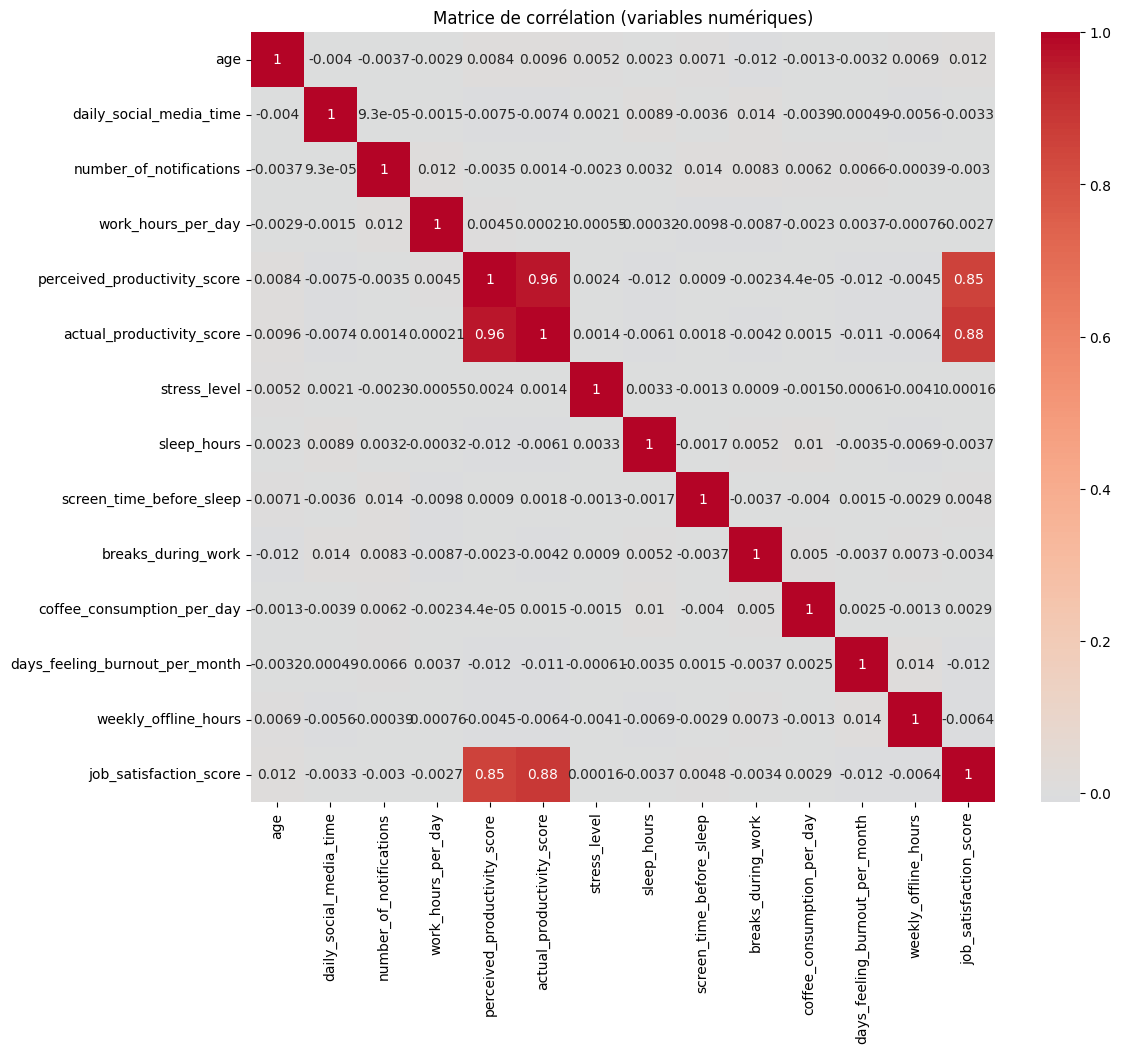

In [12]:
# Calcul et affichage de la matrice de corrélation
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (variables numériques)')
plt.show()

La matrice de correlation permet de comparer les colonnes pour trouver celles dont les informations extraites peuvent avoir un lien. Celles qui ont une grande correlation sont la satisfaction au travail et la productivité.

Prise de décision: Satisfaction/Evaluation personnelle vs Productivité réelle
Selon la matrice de correlation, les correlations les plus fortes sont trouvées entre ces variables et la valeur cible. Nous cherchons à évaluer l'évolution de la productivité à partir de la satisfaction(job_satisfaction_score) et de l'évaluation personnelle(perceived_productivity_score). Savoir si les salariés qui se sentent productifs et heureux sont réellement productifs et inversement. On les compare avec le stress, les heures de sommeil, et le temps de travail et de réseaux sociaux par jour qui sont réputés pour etre des facteurs déterminants dans la productivité.

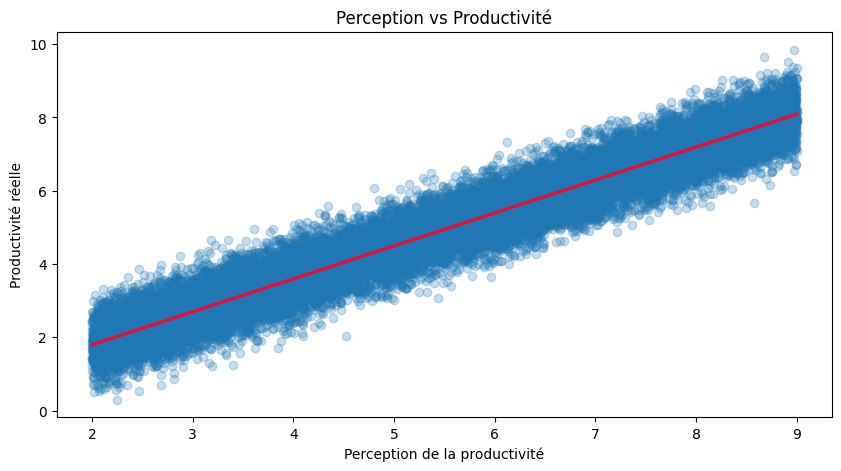

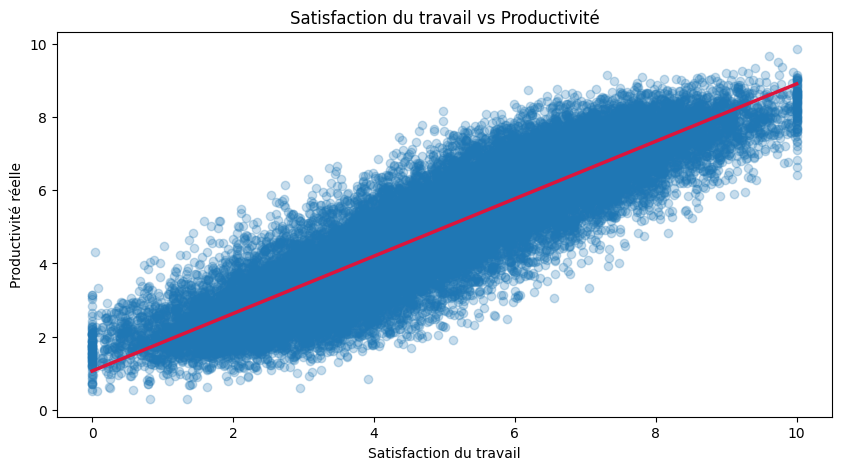

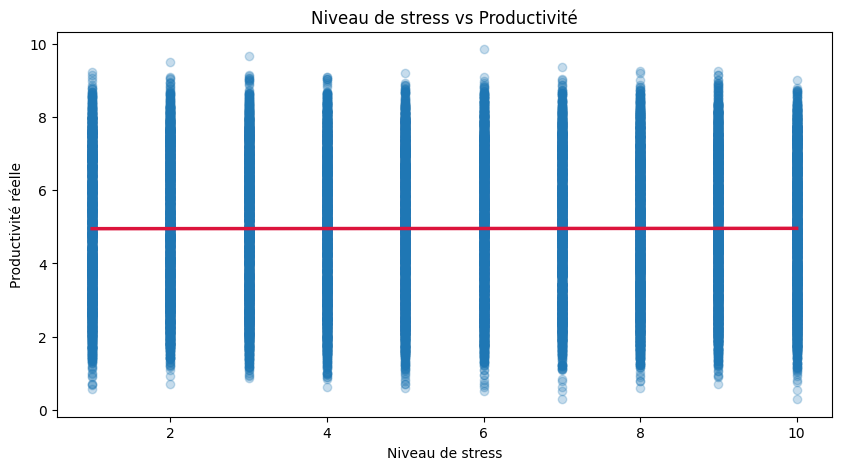

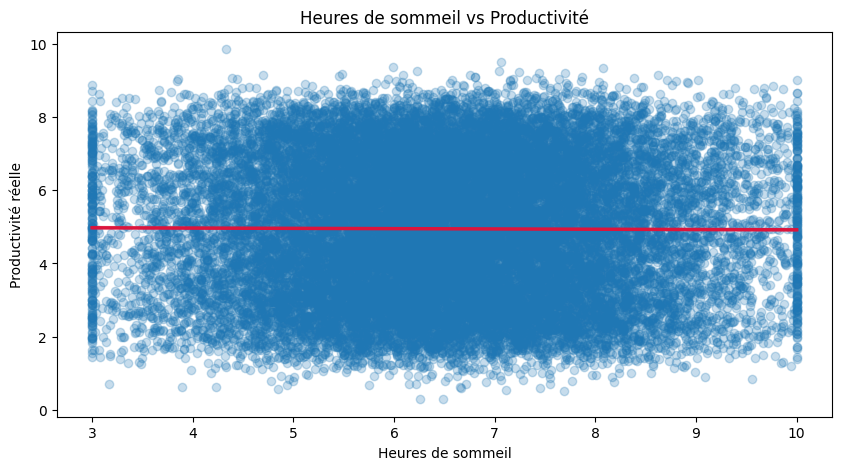

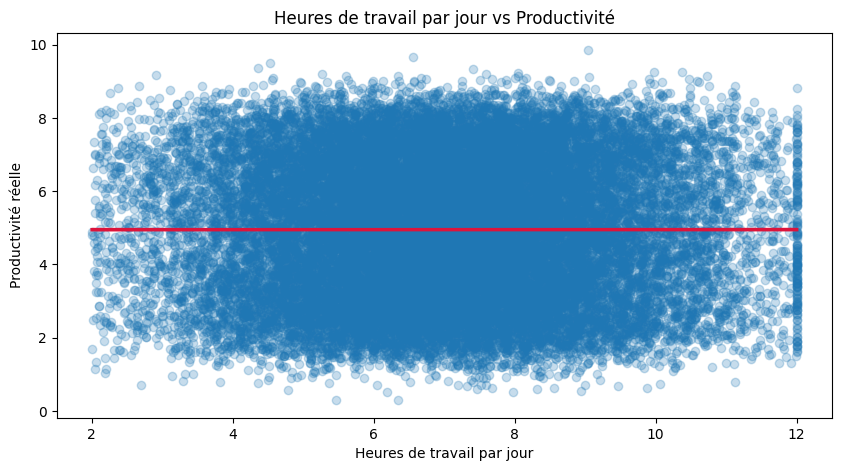

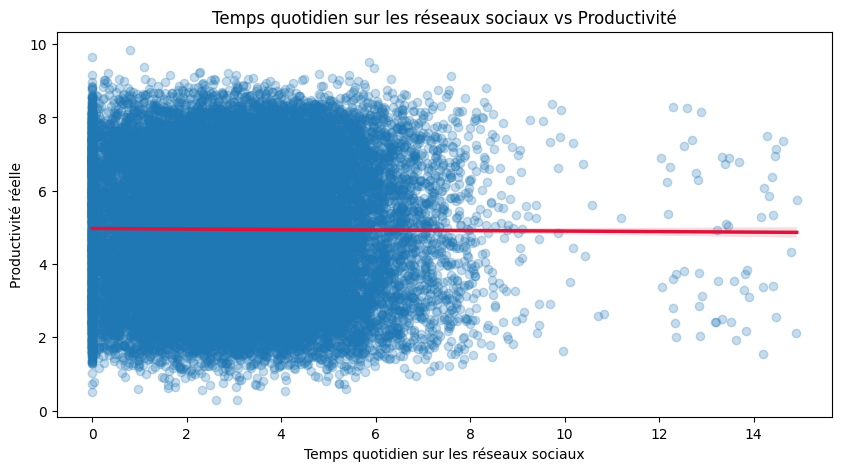

In [24]:
plt.figure(figsize=(10,5))
sns.regplot(x='perceived_productivity_score', y='actual_productivity_score', data=df
            , scatter_kws={'alpha': 0.25}, line_kws={'color': 'crimson', 'linewidth': 2.5})    
plt.title('Perception vs Productivité')
plt.xlabel('Perception de la productivité')  
plt.ylabel('Productivité réelle')
plt.show()

plt.figure(figsize=(10,5))
sns.regplot(
    x='job_satisfaction_score',
    y='actual_productivity_score',
    data=df,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)
plt.title('Satisfaction du travail vs Productivité')
plt.xlabel('Satisfaction du travail')  
plt.ylabel('Productivité réelle')
plt.show()

plt.figure(figsize=(10,5))
sns.regplot(
    x='stress_level',
    y='actual_productivity_score',
    data=df,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)
plt.title('Niveau de stress vs Productivité')
plt.xlabel('Niveau de stress')  
plt.ylabel('Productivité réelle')
plt.show()

plt.figure(figsize=(10,5))
sns.regplot(
    x='sleep_hours',
    y='actual_productivity_score',
    data=df,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)
plt.title('Heures de sommeil vs Productivité')
plt.xlabel('Heures de sommeil')  
plt.ylabel('Productivité réelle')
plt.show()

plt.figure(figsize=(10,5))
sns.regplot(
    x='work_hours_per_day',
    y='actual_productivity_score',
    data=df,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)
plt.title('Heures de travail par jour vs Productivité')
plt.xlabel('Heures de travail par jour')  
plt.ylabel('Productivité réelle')
plt.show()

plt.figure(figsize=(10,5))
sns.regplot(
    x='daily_social_media_time',
    y='actual_productivity_score',
    data=df,
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'crimson', 'linewidth': 2.5}
)
plt.title('Temps quotidien sur les réseaux sociaux vs Productivité')
plt.xlabel('Temps quotidien sur les réseaux sociaux')  
plt.ylabel('Productivité réelle')
plt.show()

On peut voir que les deux premières tendances donne une courbe d'augmentation linéaire. Cela suggère que la productivité réelle évolue en fonction de la satisfaction et l'évaluation personnelle au contraire des quatre dernières tendances qui donne juste une ligne droite. Cela confirme le résultat de la matrice de correlation.

Splitting

In [25]:
df_clean = df.dropna(subset=["actual_productivity_score"])

X = df_clean.drop("actual_productivity_score", axis=1)
y = df_clean["actual_productivity_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing

On standardise l'age, les valeurs en heures et en jours pour qu'elles puissent etre exprimées dans un ordre de grandeur équivalent avec une moyenne ramenée à 0. 
Les valeurs discrètes sont 'number_of_notifications', 'days_feeling_burnout_per_month' et les valeurs continues sont 'daily_social_media_time', 'work_hours_per_day', 'sleep_hours', 'screen_time_before_sleep', 'weekly_offline_hours'.

Pour les valeurs catégorielles, on utilise un encodage en OneHotEncoding, comme ce sont des valeurs nominales et qu'elles ont chacune moins de 6 valeurs. Elles ne suscitent aucun ordre naturel.

In [55]:
num_features = ['job_satisfaction_score','perceived_productivity_score','age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'sleep_hours', 'screen_time_before_sleep', 'days_feeling_burnout_per_month', 'weekly_offline_hours','coffee_consumption_per_day', 'stress_level', 'breaks_during_work']
cat_features = ['gender', 'job_type', 'social_platform_preference']

numeric_pipeline = Pipeline([('num_imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('cat_features', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_pipeline, num_features), ('cat', categorical_pipeline, cat_features)])

## RandomForest 
peut etre perfomant pour ce type de prédiction car la productivité n’évolue pas forcément de façon linéaire avec les variables(par exemple un salarié qui travaille plus d'heures peut etre moins productif qu'un autre qui travaille moins).

La colonne à prédire est le score de productivité réel(actual_productivity_score)

In [41]:
rf = RandomForestRegressor(
    max_depth=8,
    min_samples_leaf=3,
    n_estimators=100,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
], verbose=True)

Comme hyperpamètres, nous avons choisi max_depth pour limiter la profondeur des arbres afin d'éviter le surapprentissage, min_sample_leaf pour limiter le nombre d'echantillon minimum de chaque feuille pour éviter les valeurs extremes, n_estimators pour définir le nombre d'arbres, random_state pour s'assurer que les arbres sont entrainés sur un echantillon aléatoire de données.

Les meilleures performances du modèle ont été atteintes avec ces valeurs d'hyperparamètres, une profondeur 8 des arbres pour des prévisions lissées et simples sans risque de surapprentissage, 3 pour les echantillons de chaque feuille pour généraliser le cas sans exclure trop de valeurs.

Nous avons choisi les métriques d'évaluation MAE, pour mesurer la valeur moyenne absolue d'erreur du modèle, MSE pour détecter si le modèle fait de grosses erreurs et R2 pour évaluer la capacité du modèle à expliquer les données réelles.

In [58]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2:", r2_rf)
print("RMSE:", rmse_rf)

[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.2s
[Pipeline] ............. (step 2 of 2) Processing model, total=  20.6s
MAE: 0.39029211491411614
MSE: 0.25873127231192744
R2: 0.92590236898858
RMSE: 0.5086563400882048


Selon MAE, le modèle se trompe donc en moyenne de 0.39 sur ses prédictions. Comme le MSE est de 0.25, et le RMSE est de 0.5 le modèle a certaines limites, notamment pour éviter les grosses erreurs, par contre comme R2 est proche de 1 alors le modèle est assez performant dans la prédiction.

In [59]:
import joblib
joblib.dump(pipeline, "random_forest_california.pkl")
loaded_model = joblib.load("random_forest_california.pkl")
y_pred_loaded = loaded_model.predict(X_test)
print("R2 (modèle chargé):", r2_score(y_test, y_pred_loaded))
print("RMSE (modèle chargé):", np.sqrt(mean_squared_error(y_test, y_pred_loaded)))
print("MAE (modèle chargé):", (mean_absolute_error(y_test, y_pred_loaded)))
print("MSE (modèle chargé):", (mean_squared_error(y_test, y_pred_loaded)))

R2 (modèle chargé): 0.92590236898858
RMSE (modèle chargé): 0.5086563400882048
MAE (modèle chargé): 0.39029211491411614
MSE (modèle chargé): 0.25873127231192744


Importance des variables dans la prédiction

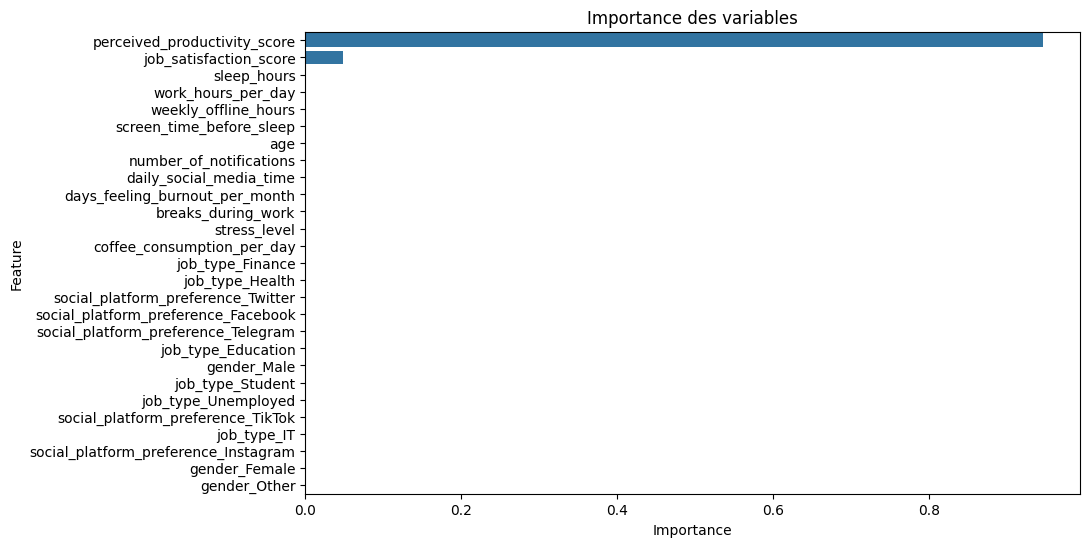

                                 Feature  Importance
1           perceived_productivity_score    0.946417
0                 job_satisfaction_score    0.048281
6                            sleep_hours    0.000719
5                     work_hours_per_day    0.000610
9                   weekly_offline_hours    0.000569
7               screen_time_before_sleep    0.000543
2                                    age    0.000489
4                number_of_notifications    0.000478
3                daily_social_media_time    0.000460
8         days_feeling_burnout_per_month    0.000354
12                    breaks_during_work    0.000265
11                          stress_level    0.000235
10            coffee_consumption_per_day    0.000153
17                      job_type_Finance    0.000044
18                       job_type_Health    0.000043
26    social_platform_preference_Twitter    0.000037
22   social_platform_preference_Facebook    0.000036
24   social_platform_preference_Telegram    0.

In [38]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
rf_model = pipeline.named_steps["model"]
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Importance des variables')
plt.show()
print(feature_importance_df)

Cela est cohérent avec la matrice de correlation, avec l'auto-évaluation de la productivité par chaque salarié(perceived_productivity_score) qui est fortement correlée avec la colonne à deviner(le score de productivité réel) et le taux de satisfaction au travail (job_satisfaction_score) qui est la deuxième en terme de correlation. 

ExtraTrees Regressor

In [60]:
from sklearn.ensemble import ExtraTreesRegressor
et_regressor = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)

et_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", et_regressor)
], verbose=True)

et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)
mse_et = mean_squared_error(y_test, y_pred_et)
rmse_et = np.sqrt(mse_et)
mae_et = mean_absolute_error(y_test, y_pred_et)
r2_et = r2_score(y_test, y_pred_et)

print("ExtraTrees - MAE:", mean_absolute_error(y_test, y_pred_et))
print("ExtraTrees - MSE:", mean_squared_error(y_test, y_pred_et))
print("ExtraTrees - R2:", r2_score(y_test, y_pred_et))
print("ExtraTrees - RMSE:", rmse_et)

[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.2s
[Pipeline] ............. (step 2 of 2) Processing model, total=   6.5s
ExtraTrees - MAE: 0.40010797623306266
ExtraTrees - MSE: 0.2774293505279409
ExtraTrees - R2: 0.9205474565812292
ExtraTrees - RMSE: 0.5267156258627048


In [63]:
#Tableau de comparaison des modèles
results = pd.DataFrame({
    'Model': ['ExtraTreesRegressor', 'RandomForestRegressor'],
    'MAE': [mae_et, mae_rf],
    'MSE': [mse_et, mse_rf],
    'RMSE': [rmse_et, rmse_rf],
    'R2': [r2_et, r2_rf]
})

# Tri par RMSE
results = results.sort_values(by='RMSE')

print(results)

                   Model       MAE       MSE      RMSE        R2
1  RandomForestRegressor  0.390292  0.258731  0.508656  0.925902
0    ExtraTreesRegressor  0.400108  0.277429  0.526716  0.920547


Le modèle RandomForest fait donc moins d'erreurs car il a un meilleur RMSE, MSE et MAE.

Arbre de décision pour la prédiction

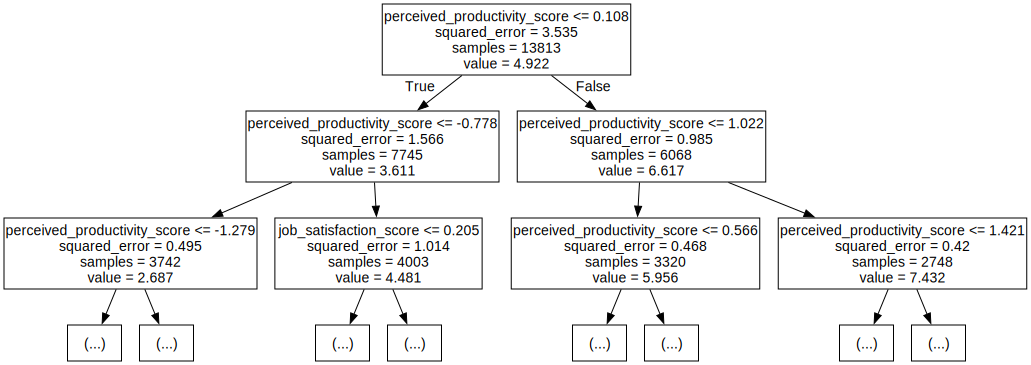

In [75]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
tree = pipeline.named_steps["model"].estimators_[0]

import os 
from graphviz import Source
from sklearn.tree import export_graphviz 
export_graphviz(tree, out_file=os.path.join("iris_tree.dot"), feature_names=list(feature_names), max_depth=2) 
Source.from_file(os.path.join("iris_tree.dot")) 

13-Modèle non supervisé: Kmeans peut etre un bon algorithme pour segmenter les profils 

Pour le processing, nous avons uniquement pris des variables numériques pour diminuer le calcul et ainsi améliorer les performances. 

C:\Users\mrand\AppData\Local\Temp\ipykernel_20524\3142218767.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['daily_social_media_time'].fillna(df['daily_social_media_time'].median(), inplace=True)


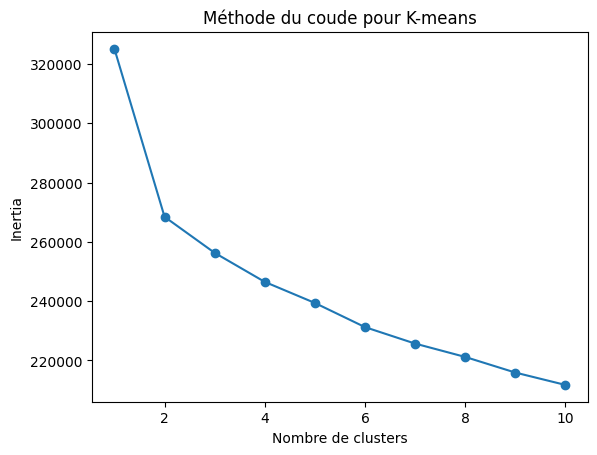

In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df['daily_social_media_time'].fillna(df['daily_social_media_time'].median(), inplace=True)
num_features = ['actual_productivity_score','job_satisfaction_score','perceived_productivity_score','age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'sleep_hours', 'screen_time_before_sleep', 'days_feeling_burnout_per_month', 'weekly_offline_hours']

numeric_pipeline = Pipeline([('num_imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

#Déterminer le meilleur cluster
inertia = []
for k in range(1, 11):
    kmeans_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=k, random_state=42)) 
])
    kmeans_pipeline.fit(df)
    inertia.append(kmeans_pipeline.named_steps['kmeans'].inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertia')
plt.title('Méthode du coude pour K-means')
plt.show()

On remarque que grace à la méthode du coude, il y a beaucoup de diminution entre 1 et 2. Cela signifie qu'augmenter le nombre de clusters de 1 à 2 améliore beaucoup la structure de la segmentation. Par contre, à partir de 3 jusqu'à 7, la diminution ralentit, cela signifie que l'augmentation de clusters ne modifie plus aussi nettement la structure de la segmentation. Après 7, la diminution est linéaire.  Donc, les nombres de 2 à 7 peuvent etre des bons candidats pour le nombre de clusters.

Pour confirmer le meilleur, on calcule le score de silhouette.

In [77]:
X_transformed = preprocessor.fit_transform(df)

best_score = -1
best_k = 0

for k in range(2, 7):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_transformed)
    
    score = silhouette_score(X_transformed, labels)
    
    print(f"k={k}, silhouette={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"Meilleur nombre de clusters : {best_k}")
print(f"Meilleur silhouette score : {best_score:.4f}")

k=2, silhouette=0.1570
k=3, silhouette=0.1055
k=4, silhouette=0.0759
k=5, silhouette=0.0719
k=6, silhouette=0.0716
Meilleur nombre de clusters : 2
Meilleur silhouette score : 0.1570


Tous les clusters sont très faibles, cela veut dire qu'aucun nombre de cluster ne se démarque réellement. Mais le meilleur nombre de clusters est 2.

In [78]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_transformed)

df["cluster"] = labels
df["cluster"].value_counts()

cluster
0    14898
1    14651
Name: count, dtype: int64

Réduction de dimension PCA

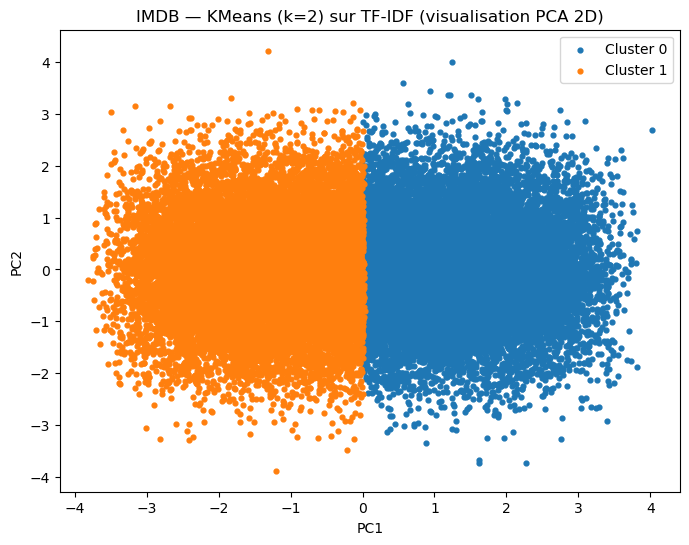

In [38]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_transformed)

plt.figure(figsize=(8,6))

mask0 = df["cluster"] == 0
mask1 = df["cluster"] == 1

plt.scatter(X_vis[mask0, 0], X_vis[mask0, 1], s=12, label="Cluster 0")
plt.scatter(X_vis[mask1, 0], X_vis[mask1, 1], s=12, label="Cluster 1")

plt.title("IMDB — KMeans (k=2) sur TF-IDF (visualisation PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

On remarque une distribution équilibrée des profils entre les 2 clusters selon sur l'axe de PC1. Donc il n'y a qu'un facteur de segmentation.

In [40]:
cols = ['actual_productivity_score','job_satisfaction_score','perceived_productivity_score','age', 
        'daily_social_media_time','number_of_notifications','work_hours_per_day',
        'sleep_hours','screen_time_before_sleep','days_feeling_burnout_per_month',
        'weekly_offline_hours']

# Moyennes pour chaque cluster
cluster_means = df.groupby('cluster')[cols].mean()
print(cluster_means)

         actual_productivity_score  job_satisfaction_score  \
cluster                                                      
0                         6.420230                6.491174   
1                         3.484544                3.437329   

         perceived_productivity_score        age  daily_social_media_time  \
cluster                                                                     
0                            7.141005  41.540483                 3.074164   
1                            3.882836  41.433293                 3.136517   

         number_of_notifications  work_hours_per_day  sleep_hours  \
cluster                                                             
0                      59.926971            6.980416     6.482567   
1                      59.990537            7.001161     6.517584   

         screen_time_before_sleep  days_feeling_burnout_per_month  \
cluster                                                             
0                        1.

Nous regardons la moyenne des variables pour déterminer le facteur de segmentation PC1. On remarque que la productivité réelle, le sentiment de productivité et la satisfaction au travail ont une répartition désequilibrée pour les 2 clusters au contraire des autres variables. De plus, les valeurs de la productivité réelle et de la satisfaction au travail sont les valeurs les plus proches pour les 2 clusters.
Interprétation:
Cluster 0 est beaucoup plus satisfait de son travail. Cluster 0 se perçoit comme beaucoup plus productif. Cluster 0 est réellement plus productif également. Au sujet des autres variables, les deux clusters n'ont pas beaucoup de différence et sont assez équilibrés. Ainsi les attributs qui peuvent segmenter les profils sont les facteurs productivité/satisfaction, car selon l'observation, ceux qui sont les plus satisfaits sont les plus productifs au travail et ceux qui sont les moins satisfaits sont les moins productifs. Cela explique pourquoi le score de productivité reélle en moyenne est assez proche de celui de la satisfaction au travail. Cela explique également pourquoi la productivité réelle dans le ML supervisé depend surtout de la perception personnelle et de la satisfaction au travail.